# Transformer 模型从零实现 — 全面分析 Notebook

本 Notebook 基于 `Transformer_basic.py`，对 Transformer 模型进行**逐模块**的深度解析。

## 目录

| 章节 | 内容 |
|------|------|
| 1 | 环境准备与工具函数 |
| 2 | 核心组件：层归一化 & 残差连接 |
| 3 | 注意力机制：从 Scaled Dot-Product 到 Multi-Head |
| 4 | 前馈网络 & 嵌入层 |
| 5 | 位置编码 |
| 6 | 编码器（Encoder）|
| 7 | 解码器（Decoder）|
| 8 | 完整模型组装 |
| 9 | 模型结构可视化 |
| 10 | 关键参数说明 |
| 11 | 训练过程分析 |
| 12 | 模型性能评估 |
| 13 | 综合测试与总结 |


## 1. 环境准备与工具函数

In [1]:
import torch
import torch.nn as nn
from torch.nn.functional import log_softmax
import math
import copy
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")


PyTorch version: 2.11.0+cpu
Device: cpu


### 1.1 `clones` — 模块深拷贝工具

Transformer 中大量使用**相同结构的重复层**（如 N 个 EncoderLayer），
`clones` 函数通过 `copy.deepcopy` 生成 N 个**独立**的模块实例，
确保每个层拥有各自的参数，不会共享权重。


In [2]:
def clones(module, N):
    """深拷贝 module N 次，返回 nn.ModuleList"""
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

# 验证：每个克隆的线性层参数独立
demo_layers = clones(nn.Linear(4, 4), 3)
print(f"克隆数量: {len(demo_layers)}")
print(f"参数是否共享: {demo_layers[0].weight.data_ptr() == demo_layers[1].weight.data_ptr()}")


克隆数量: 3
参数是否共享: False


## 2. 核心组件：层归一化 & 残差连接

### 2.1 LayerNorm（层归一化）

对每个样本的**最后一个维度**（即特征维度）做归一化：

$$\text{LayerNorm}(x) = \frac{a_2 \cdot (x - \mu)}{\sigma + \epsilon} + b_2$$

- `a_2`（gamma）：可学习的缩放参数，初始化为 1
- `b_2`（beta）：可学习的偏移参数，初始化为 0
- `eps`：防止除零的小常数（默认 1e-6）

**为什么用 LayerNorm 而不是 BatchNorm？**
- BatchNorm 依赖 batch 统计量，batch 小时不稳定
- LayerNorm 对每个样本独立归一化，不受 batch 大小影响
- 在序列模型中更稳定、更适合变长输入


In [3]:
class LayerNorm(nn.Module):
    def __init__(self, features, eps=1e-6):
        super(LayerNorm, self).__init__()
        self.a_2 = nn.Parameter(torch.ones(features))   # gamma: 缩放
        self.b_2 = nn.Parameter(torch.zeros(features))  # beta: 偏移
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)   # 沿特征维求均值
        std = x.std(-1, keepdim=True)     # 沿特征维求标准差
        return self.a_2 * (x - mean) / (std + self.eps) + self.b_2

# 演示 LayerNorm 的效果
ln = LayerNorm(4)
x_demo = torch.tensor([[1.0, 2.0, 3.0, 4.0], [10.0, 20.0, 30.0, 40.0]])
y_demo = ln(x_demo)
print("输入:")
print(x_demo)
print("\nLayerNorm 输出:")
print(y_demo)
print(f"\n每行均值: {y_demo.mean(dim=-1).tolist()}")
print(f"每行标准差: {y_demo.std(dim=-1).tolist()}")


输入:
tensor([[ 1.,  2.,  3.,  4.],
        [10., 20., 30., 40.]])

LayerNorm 输出:
tensor([[-1.1619, -0.3873,  0.3873,  1.1619],
        [-1.1619, -0.3873,  0.3873,  1.1619]], grad_fn=<AddBackward0>)

每行均值: [2.9802322387695312e-08, 0.0]
每行标准差: [0.9999992847442627, 0.9999999403953552]


### 2.2 SublayerConnection — 残差连接 + LayerNorm

Transformer 中每个子层（Self-Attention / FFN）都包裹在残差连接中：

$$\text{output} = x + \text{Dropout}(\text{Sublayer}(\text{LayerNorm}(x)))$$

即 **Pre-LN** 变体：先归一化，再经过子层，最后残差相加。
这种设计有助于训练深层网络时梯度的稳定传播。


In [4]:
class SublayerConnection(nn.Module):
    def __init__(self, size, dropout):
        super(SublayerConnection, self).__init__()
        self.norm = LayerNorm(size)       # 先做 LayerNorm
        self.dropout = nn.Dropout(dropout) # Dropout 正则化

    def forward(self, x, sublayer):
        # x + Dropout(Sublayer(LayerNorm(x)))
        return x + self.dropout(sublayer(self.norm(x)))


## 3. 注意力机制

### 3.1 Scaled Dot-Product Attention

核心公式：

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

步骤分解：
1. **Q × K^T**：计算查询与键的相似度
2. **除以 √d_k**：缩放防止点积过大导致 softmax 饱和
3. **Mask**：屏蔽无效位置（padding / 未来信息）
4. **Softmax**：归一化为注意力权重
5. **× V**：加权求和得到输出

> **注意**：原代码使用 `log_softmax` 而非 `softmax`，这在某些场景下更数值稳定，
> 但会影响注意力权重的概率解释。标准实现通常使用 `softmax`。


In [5]:
def attention(query, key, value, mask=None, dropout=None):
    """缩放点积注意力"""
    d_k = query.size(-1)  # 键向量维度
    # Step 1 & 2: 计算缩放点积分数
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    # Step 3: 应用掩码（将掩码位置设为 -1e9，softmax 后趋近于 0）
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    # Step 4: Softmax 归一化
    p_attn = log_softmax(scores, dim=-1)
    # Step 5: Dropout 正则化
    if dropout is not None:
        p_attn = dropout(p_attn)
    # Step 6: 加权求和
    return torch.matmul(p_attn, value), p_attn

# 可视化：简单注意力权重示例
q = torch.randn(1, 4, 8)  # [batch, seq_len, d_k]
k = torch.randn(1, 4, 8)
v = torch.randn(1, 4, 8)
out, attn_weights = attention(q, k, v)
print(f"注意力输出形状: {out.shape}")
print(f"注意力权重形状: {attn_weights.shape}")


注意力输出形状: torch.Size([1, 4, 8])
注意力权重形状: torch.Size([1, 4, 4])


### 3.2 Multi-Head Attention（多头注意力）

将 d_model 维度拆分为 h 个头，每个头独立计算注意力，再拼接投影：

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) W^O$$

其中每个头：$\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$

- **4 组线性变换**：Q / K / V 各一组 + 输出投影
- `d_k = d_model // h`：每个头的维度
- 多头让模型能同时关注不同位置的不同表示子空间


In [6]:
class MultiHeadedAttention(nn.Module):
    def __init__(self, h, d_model, dropout=0.1):
        super(MultiHeadedAttention, self).__init__()
        assert d_model % h == 0  # d_model 必须能被 h 整除
        self.d_k = d_model // h  # 每个头的维度
        self.h = h               # 头数
        # 4 个线性层: Q投影, K投影, V投影, 输出投影
        self.linears = clones(nn.Linear(d_model, d_model), 4)
        self.attn = None         # 保存注意力权重（用于可视化）
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, query, key, value, mask=None):
        if mask is not None:
            mask = mask.unsqueeze(1)  # [batch, 1, 1, seq_len] 广播到所有头
        nbatches = query.size(0)
        # Step 1: 线性投影 + 拆分为多头
        query, key, value = [
            l(x).view(nbatches, -1, self.h, self.d_k).transpose(1, 2)
            for l, x in zip(self.linears, (query, key, value))
        ]
        # Step 2: 计算注意力
        x, self.attn = attention(query, key, value, mask=mask, dropout=self.dropout)
        # Step 3: 拼接多头 + 输出投影
        x = x.transpose(1, 2).contiguous().view(nbatches, -1, self.h * self.d_k)
        return self.linears[-1](x)

# 演示多头注意力
mha = MultiHeadedAttention(h=8, d_model=512)
q = torch.randn(2, 10, 512)
out = mha(q, q, q)  # 自注意力: Q=K=V
print(f"输入形状: {q.shape}")
print(f"输出形状: {out.shape}")
print(f"每个头维度 d_k: {mha.d_k}")


输入形状: torch.Size([2, 10, 512])
输出形状: torch.Size([2, 10, 512])
每个头维度 d_k: 64


## 4. 前馈网络 & 嵌入层

### 4.1 PositionwiseFeedForward（位置前馈网络）

对每个位置独立应用相同的两层 MLP：

$$\text{FFN}(x) = W_2 \cdot \text{ReLU}(W_1 x)$$

- `d_model → d_ff`：先升维（通常 d_ff = 4 × d_model）
- `d_ff → d_model`：再降维回原始维度
- 升维让模型在更高维空间学习非线性特征变换


In [7]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)  # 升维
        self.w_2 = nn.Linear(d_ff, d_model)  # 降维
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(torch.relu(self.w_1(x))))

# 演示
ffn = PositionwiseFeedForward(d_model=512, d_ff=2048)
x_ffn = torch.randn(2, 10, 512)
y_ffn = ffn(x_ffn)
print(f"FFN 输入: {x_ffn.shape} -> 输出: {y_ffn.shape}")
print(f"升维: 512 -> 2048 -> 512")


FFN 输入: torch.Size([2, 10, 512]) -> 输出: torch.Size([2, 10, 512])
升维: 512 -> 2048 -> 512


### 4.2 Embeddings（词嵌入层）

将离散的词 ID 映射为连续向量，并乘以 $\sqrt{d_{model}}$ 缩放：

$$\text{Embed}(x) = \text{LookupTable}(x) \times \sqrt{d_{model}}$$

缩放的原因：让嵌入值的量级与位置编码匹配，
因为位置编码的值域约为 [-1, 1]，而默认嵌入初始化值较小。


In [8]:
class Embeddings(nn.Module):
    def __init__(self, d_model, vocab):
        super(Embeddings, self).__init__()
        self.lut = nn.Embedding(vocab, d_model)  # 查找表
        self.d_model = d_model

    def forward(self, x):
        return self.lut(x) * math.sqrt(self.d_model)  # 缩放

# 演示
emb = Embeddings(d_model=512, vocab=10000)
tokens = torch.LongTensor([[1, 2, 3, 4, 5]])
embedded = emb(tokens)
print(f"输入 token IDs: {tokens.shape}")
print(f"嵌入输出: {embedded.shape}")
print(f"缩放因子 sqrt(512) = {math.sqrt(512):.2f}")


输入 token IDs: torch.Size([1, 5])
嵌入输出: torch.Size([1, 5, 512])
缩放因子 sqrt(512) = 22.63


## 5. 位置编码（Positional Encoding）

Transformer 没有循环结构，无法感知位置信息。位置编码通过正弦/余弦函数注入位置：

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

- **偶数维度**用 sin，**奇数维度**用 cos
- 波长从 $2\pi$ 到 $10000 \times 2\pi$，形成多尺度位置信号
- 任意固定偏移 $k$，$PE_{pos+k}$ 可表示为 $PE_{pos}$ 的线性函数，便于学习相对位置


In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        # 预计算位置编码矩阵
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)  # [max_len, 1]
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model)
        )  # [d_model/2]
        pe[:, 0::2] = torch.sin(position * div_term)  # 偶数列
        pe[:, 1::2] = torch.cos(position * div_term)  # 奇数列
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer("pe", pe)  # 不参与梯度计算

    def forward(self, x):
        x = x + self.pe[:, : x.size(1)].requires_grad_(False)
        return self.dropout(x)


### 5.1 位置编码可视化

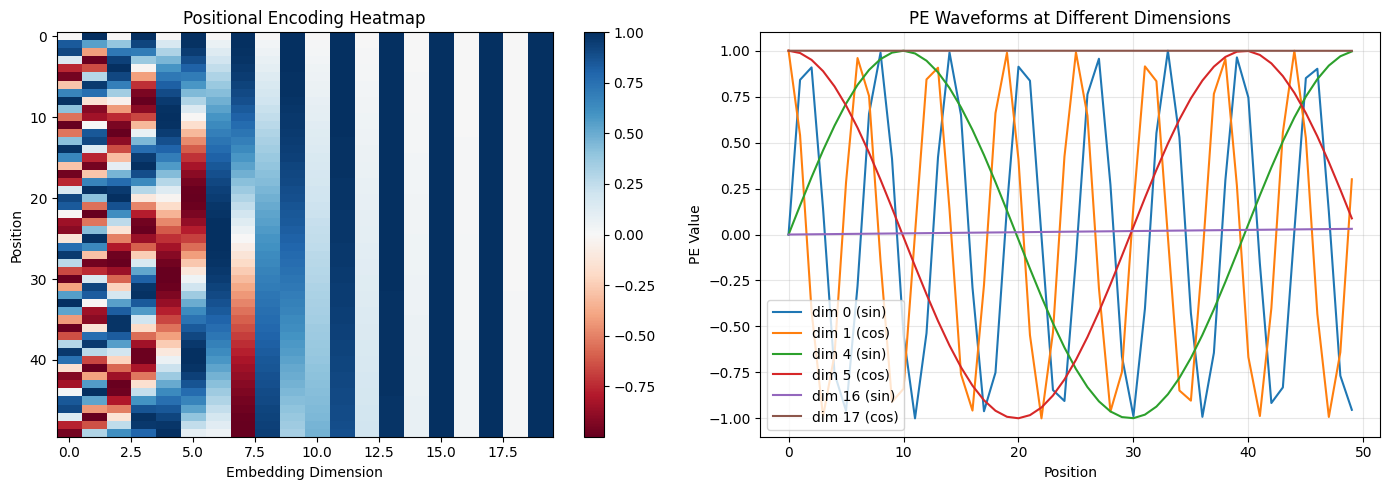

In [10]:
# 可视化位置编码
pe = PositionalEncoding(20, 0)
y = pe.forward(torch.zeros(1, 100, 20))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：位置编码热力图
pe_data = pe.pe[0, :50, :].numpy()
im = axes[0].imshow(pe_data, aspect="auto", cmap="RdBu")
axes[0].set_xlabel("Embedding Dimension")
axes[0].set_ylabel("Position")
axes[0].set_title("Positional Encoding Heatmap")
plt.colorbar(im, ax=axes[0])

# 右图：不同维度的正弦/余弦波形
dims = [0, 1, 4, 5, 16, 17]
positions = np.arange(50)
for d in dims:
    func = "sin" if d % 2 == 0 else "cos"
    axes[1].plot(positions, pe_data[:, d], label=f"dim {d} ({func})")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("PE Value")
axes[1].set_title("PE Waveforms at Different Dimensions")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. 编码器（Encoder）

### 6.1 EncoderLayer

每个编码器层包含两个子层：
1. **多头自注意力**：每个位置关注输入序列的所有位置
2. **前馈网络**：对每个位置独立变换

每个子层都有残差连接 + LayerNorm。


In [11]:
class EncoderLayer(nn.Module):
    def __init__(self, size, self_attn, feed_forward, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = self_attn     # 多头自注意力
        self.feed_forward = feed_forward  # 前馈网络
        self.sublayer = clones(SublayerConnection(size, dropout), 2)  # 2 个残差连接
        self.size = size

    def forward(self, x, mask):
        # 子层1: 多头自注意力 (Q=K=V=x)
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, mask))
        # 子层2: 前馈网络
        return self.sublayer[1](x, self.feed_forward)


### 6.2 Encoder

堆叠 N 个 EncoderLayer，最后再做一次 LayerNorm。


In [12]:
class Encoder(nn.Module):
    def __init__(self, layer, N):
        super(Encoder, self).__init__()
        self.layers = clones(layer, N)  # N 个编码器层
        self.norm = LayerNorm(layer.size)  # 最终归一化

    def forward(self, x, mask):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)


## 7. 解码器（Decoder）

### 7.1 DecoderLayer

每个解码器层包含**三个**子层：
1. **掩码自注意力**：只能看到已生成的位置（防止信息泄露）
2. **交叉注意力**：Query 来自解码器，Key/Value 来自编码器输出
3. **前馈网络**：对每个位置独立变换


In [13]:
class DecoderLayer(nn.Module):
    def __init__(self, size, self_attn, src_attn, feed_forward, dropout):
        super(DecoderLayer, self).__init__()
        self.size = size
        self.self_attn = self_attn   # 掩码自注意力
        self.src_attn = src_attn     # 交叉注意力
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 3)  # 3 个残差连接

    def forward(self, x, memory, src_mask, tgt_mask):
        m = memory  # 编码器输出
        # 子层1: 掩码自注意力 (Q=K=V=x, mask=tgt_mask)
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, tgt_mask))
        # 子层2: 交叉注意力 (Q=x, K=V=memory, mask=src_mask)
        x = self.sublayer[1](x, lambda x: self.src_attn(x, m, m, src_mask))
        # 子层3: 前馈网络
        return self.sublayer[2](x, self.feed_forward)


### 7.2 Decoder

堆叠 N 个 DecoderLayer，最后再做一次 LayerNorm。


In [14]:
class Decoder(nn.Module):
    def __init__(self, layer, N):
        super(Decoder, self).__init__()
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size)

    def forward(self, x, memory, src_mask, tgt_mask):
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)


### 7.3 subsequent_mask — 因果掩码

生成下三角掩码矩阵，确保位置 i 只能关注位置 ≤ i：


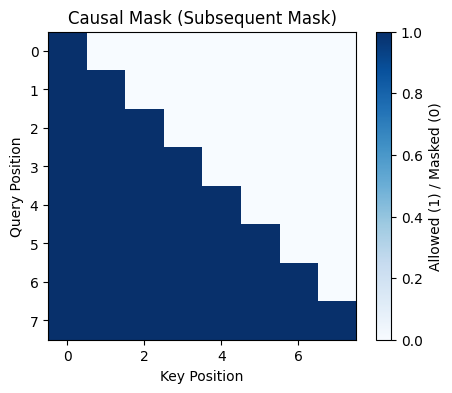

掩码矩阵 (1=可见, 0=遮蔽):
[[1 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0]
 [1 1 1 0 0 0 0 0]
 [1 1 1 1 0 0 0 0]
 [1 1 1 1 1 0 0 0]
 [1 1 1 1 1 1 0 0]
 [1 1 1 1 1 1 1 0]
 [1 1 1 1 1 1 1 1]]


In [15]:
def subsequent_mask(size):
    """生成下三角掩码，防止解码器看到未来信息"""
    attn_shape = (1, size, size)
    subsequent_mask = torch.triu(
        torch.ones(attn_shape), diagonal=1
    ).type(torch.uint8)
    return subsequent_mask == 0  # 下三角为 True(1)，上三角为 False(0)

# 可视化因果掩码
mask = subsequent_mask(8)
plt.figure(figsize=(5, 4))
plt.imshow(mask[0].numpy(), cmap="Blues")
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.title("Causal Mask (Subsequent Mask)")
plt.colorbar(label="Allowed (1) / Masked (0)")
plt.show()
print("掩码矩阵 (1=可见, 0=遮蔽):")
print(mask[0].int().numpy())


## 8. 完整模型组装

### 8.1 Generator — 输出投影

将解码器输出从 d_model 维投影到词汇表大小，并应用 log_softmax。


In [16]:
class Generator(nn.Module):
    def __init__(self, d_model, vocab):
        super(Generator, self).__init__()
        self.proj = nn.Linear(d_model, vocab)  # d_model -> vocab_size

    def forward(self, x):
        return log_softmax(self.proj(x), dim=-1)


### 8.2 EncoderDecoder — 完整 Transformer

整合编码器、解码器、嵌入层和生成器：

```
输入 src -> [src_embed] -> [Encoder] -> memory
                                          |
输入 tgt -> [tgt_embed] -> [Decoder] ----+ -> [Generator] -> 输出
```


In [17]:
class EncoderDecoder(nn.Module):
    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
        super(EncoderDecoder, self).__init__()
        self.encoder = encoder       # 编码器
        self.decoder = decoder       # 解码器
        self.src_embed = src_embed   # 源语言嵌入
        self.tgt_embed = tgt_embed   # 目标语言嵌入
        self.generator = generator   # 输出投影

    def forward(self, src, tgt, src_mask, tgt_mask):
        return self.decode(self.encode(src, src_mask), src_mask, tgt, tgt_mask)

    def encode(self, src, src_mask):
        return self.encoder(self.src_embed(src), src_mask)

    def decode(self, memory, src_mask, tgt, tgt_mask):
        return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)


### 8.3 `make_model` — 模型构建函数

一键构建完整 Transformer 模型，使用 Xavier 初始化。


In [18]:
def make_model(src_vocab, tgt_vocab, N=6, d_model=512, d_ff=2048, h=8, dropout=0.1):
    """构建完整 Transformer 模型

    参数:
        src_vocab: 源语言词汇表大小
        tgt_vocab: 目标语言词汇表大小
        N:        编码器/解码器层数 (默认 6)
        d_model:  模型维度 (默认 512)
        d_ff:     前馈网络隐藏层维度 (默认 2048)
        h:        注意力头数 (默认 8)
        dropout:  Dropout 比率 (默认 0.1)
    """
    c = copy.deepcopy
    attn = MultiHeadedAttention(h, d_model)
    ff = PositionwiseFeedForward(d_model, d_ff, dropout)
    position = PositionalEncoding(d_model, dropout)

    model = EncoderDecoder(
        Encoder(EncoderLayer(d_model, c(attn), c(ff), dropout), N),
        Decoder(DecoderLayer(d_model, c(attn), c(attn), c(ff), dropout), N),
        nn.Sequential(Embeddings(d_model, src_vocab), c(position)),
        nn.Sequential(Embeddings(d_model, tgt_vocab), c(position)),
        Generator(d_model, tgt_vocab),
    )

    # Xavier 初始化: 让每层输出的方差大致相等
    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
    return model

# 构建模型并查看参数量
model = make_model(src_vocab=11, tgt_vocab=11, N=2)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"总参数量: {total_params:,}")
print(f"可训练参数量: {trainable_params:,}")


总参数量: 14,731,787
可训练参数量: 14,731,787


## 9. 模型结构可视化

### 9.1 模型层级结构打印


In [19]:
# 打印模型层级结构
print(model)


EncoderDecoder(
  (encoder): Encoder(
    (layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (self_attn): MultiHeadedAttention(
          (linears): ModuleList(
            (0-3): 4 x Linear(in_features=512, out_features=512, bias=True)
          )
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (feed_forward): PositionwiseFeedForward(
          (w_1): Linear(in_features=512, out_features=2048, bias=True)
          (w_2): Linear(in_features=2048, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sublayer): ModuleList(
          (0-1): 2 x SublayerConnection(
            (norm): LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
      )
    )
    (norm): LayerNorm()
  )
  (decoder): Decoder(
    (layers): ModuleList(
      (0-1): 2 x DecoderLayer(
        (self_attn): MultiHeadedAttention(
          (linears): ModuleList(
            (0-3): 4 x Linear(in_features=512, out_

### 9.2 各模块参数量统计

In [20]:
# 各模块参数量统计
modules = {
    "Encoder": model.encoder,
    "Decoder": model.decoder,
    "Src Embedding": model.src_embed,
    "Tgt Embedding": model.tgt_embed,
    "Generator": model.generator,
}

print("各模块参数量:")
print("-" * 40)
for name, mod in modules.items():
    params = sum(p.numel() for p in mod.parameters())
    print(f"{name:20s}: {params:>10,}")
print("-" * 40)
print(f"{'Total':20s}: {sum(p.numel() for p in model.parameters()):>10,}")


各模块参数量:
----------------------------------------
Encoder             :  6,305,792
Decoder             :  8,409,088
Src Embedding       :      5,632
Tgt Embedding       :      5,632
Generator           :      5,643
----------------------------------------
Total               : 14,731,787


### 9.3 Transformer 架构示意图

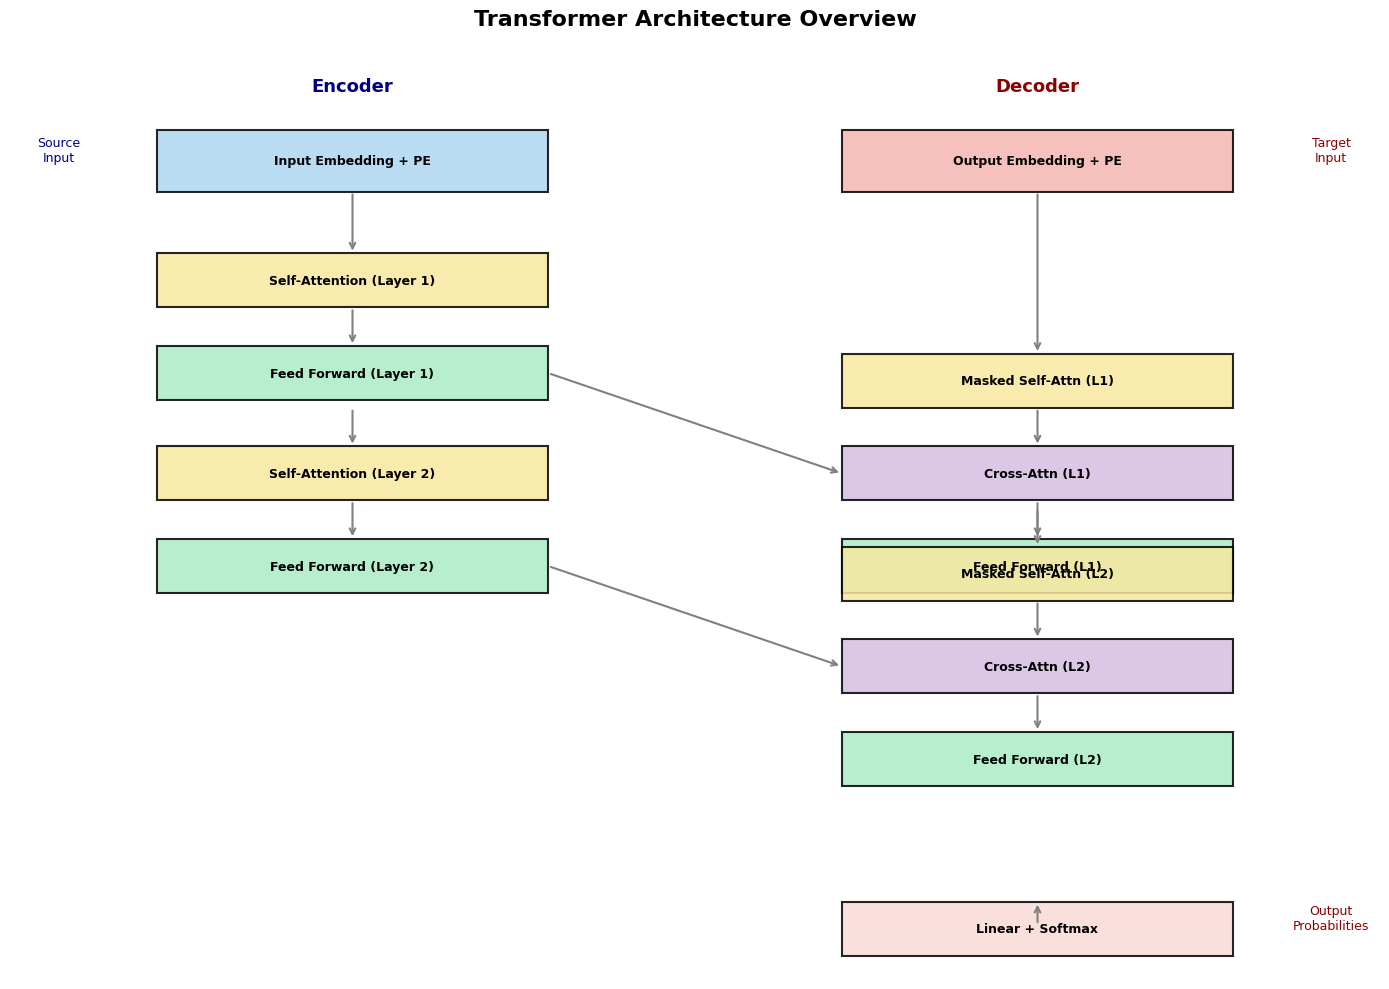

In [21]:
# 绘制 Transformer 架构示意图
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 12)
ax.axis("off")
ax.set_title("Transformer Architecture Overview", fontsize=16, fontweight="bold", pad=20)

def draw_box(ax, x, y, w, h, text, color, fontsize=9):
    rect = plt.Rectangle((x, y), w, h, fill=True, facecolor=color,
                          edgecolor="black", linewidth=1.5, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center",
            fontsize=fontsize, fontweight="bold")

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.5, color="gray"))

# Left: Encoder
ax.text(3.5, 11.5, "Encoder", ha="center", fontsize=13,
        fontweight="bold", color="navy")
draw_box(ax, 1.5, 10.2, 4, 0.8, "Input Embedding + PE", "#AED6F1")
for i in range(2):
    y_base = 7.5 - i * 2.5
    draw_box(ax, 1.5, y_base + 1.2, 4, 0.7,
             f"Self-Attention (Layer {i+1})", "#F9E79F")
    draw_box(ax, 1.5, y_base, 4, 0.7,
             f"Feed Forward (Layer {i+1})", "#ABEBC6")
    draw_arrow(ax, 3.5, 10.2 if i == 0 else y_base + 2.4,
               3.5, y_base + 1.9)
    draw_arrow(ax, 3.5, y_base + 1.2, 3.5, y_base + 0.7)

# Right: Decoder
ax.text(10.5, 11.5, "Decoder", ha="center", fontsize=13,
        fontweight="bold", color="darkred")
draw_box(ax, 8.5, 10.2, 4, 0.8, "Output Embedding + PE", "#F5B7B1")
for i in range(2):
    y_base = 5.0 - i * 2.5
    draw_box(ax, 8.5, y_base + 2.4, 4, 0.7,
             f"Masked Self-Attn (L{i+1})", "#F9E79F")
    draw_box(ax, 8.5, y_base + 1.2, 4, 0.7,
             f"Cross-Attn (L{i+1})", "#D7BDE2")
    draw_box(ax, 8.5, y_base, 4, 0.7,
             f"Feed Forward (L{i+1})", "#ABEBC6")
    draw_arrow(ax, 10.5, 10.2 if i == 0 else y_base + 3.6,
               10.5, y_base + 3.1)
    draw_arrow(ax, 10.5, y_base + 2.4, 10.5, y_base + 1.9)
    draw_arrow(ax, 10.5, y_base + 1.2, 10.5, y_base + 0.7)

# Cross-attention arrows
for i in range(2):
    y_base = 7.5 - i * 2.5
    y_cross = 5.0 - i * 2.5 + 1.55
    draw_arrow(ax, 5.5, y_base + 0.35, 8.5, y_cross)

# Generator
draw_box(ax, 8.5, 0.3, 4, 0.7, "Linear + Softmax", "#FADBD8")
draw_arrow(ax, 10.5, 0.7, 10.5, 1.0)

# Labels
ax.text(0.5, 10.6, "Source\nInput", ha="center", fontsize=9, color="navy")
ax.text(13.5, 10.6, "Target\nInput", ha="center", fontsize=9, color="darkred")
ax.text(13.5, 0.65, "Output\nProbabilities", ha="center",
        fontsize=9, color="darkred")

plt.tight_layout()
plt.show()


### 9.4 多头注意力权重可视化

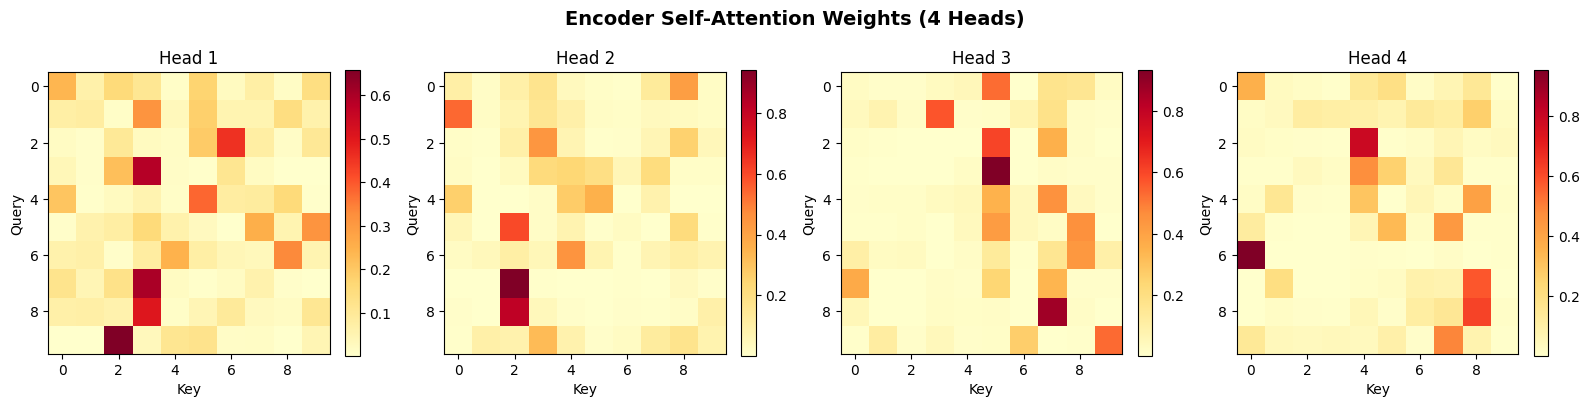

In [22]:
# 构建小模型并可视化注意力权重
small_model = make_model(11, 11, N=1, d_model=64, d_ff=256, h=4)
small_model.eval()

src = torch.LongTensor([[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]])
tgt = torch.LongTensor([[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]])
src_mask = torch.ones(1, 1, 10)
tgt_mask = subsequent_mask(10)

with torch.no_grad():
    _ = small_model(src, tgt, src_mask, tgt_mask)

# 提取编码器第一层的注意力权重
enc_attn = small_model.encoder.layers[0].self_attn
enc_attn.eval()
with torch.no_grad():
    q = small_model.src_embed(src)
    _ = enc_attn(q, q, q, src_mask)
    attn_w = enc_attn.attn  # [batch, h, seq, seq]

# 注意: 使用了 log_softmax，所以先 exp 还原
attn_probs = torch.exp(attn_w)[0].numpy()  # [h, seq, seq]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Encoder Self-Attention Weights (4 Heads)",
             fontsize=14, fontweight="bold")
for i in range(4):
    im = axes[i].imshow(attn_probs[i], cmap="YlOrRd")
    axes[i].set_title(f"Head {i+1}")
    axes[i].set_xlabel("Key")
    axes[i].set_ylabel("Query")
    plt.colorbar(im, ax=axes[i], fraction=0.046)
plt.tight_layout()
plt.show()


## 10. 关键参数说明

| 参数 | 默认值 | 说明 |
|------|--------|------|
| `N` | 6 | 编码器/解码器堆叠层数 |
| `d_model` | 512 | 模型隐藏维度（嵌入维度）|
| `d_ff` | 2048 | 前馈网络中间层维度（通常 4×d_model）|
| `h` | 8 | 多头注意力的头数 |
| `d_k` | 64 | 每个头的维度（= d_model / h）|
| `dropout` | 0.1 | Dropout 比率 |
| `max_len` | 5000 | 位置编码最大长度 |

### 参数量估算

对于原始 Transformer（N=6, d_model=512, d_ff=2048, h=8, vocab=V）：

- **注意力层**: 4 × d_model² = 4 × 512² = 1,048,576 参数/层
- **FFN层**: d_model × d_ff + d_ff × d_model = 2 × 512 × 2048 = 2,097,152 参数/层
- **每层总参数**: ~3.1M（编码器）+ ~4.2M（解码器，多一个交叉注意力）
- **嵌入层**: 2 × V × d_model


In [23]:
# 不同配置下的参数量对比
configs = [
    {"name": "Tiny",  "N": 1, "d_model": 64,  "d_ff": 256,  "h": 2, "vocab": 1000},
    {"name": "Small", "N": 2, "d_model": 128, "d_ff": 512,  "h": 4, "vocab": 5000},
    {"name": "Base",  "N": 6, "d_model": 512, "d_ff": 2048, "h": 8, "vocab": 10000},
    {"name": "Big",   "N": 6, "d_model": 1024,"d_ff": 4096, "h": 16,"vocab": 30000},
]

print(f"{'Config':10s} {'N':>4s} {'d_model':>7s} {'d_ff':>6s} {'h':>4s} {'Params':>12s}")
print("-" * 50)
for cfg in configs:
    m = make_model(cfg["vocab"], cfg["vocab"], N=cfg["N"],
                   d_model=cfg["d_model"], d_ff=cfg["d_ff"], h=cfg["h"])
    params = sum(p.numel() for p in m.parameters())
    print(f"{cfg['name']:10s} {cfg['N']:>4d} {cfg['d_model']:>7d} "
          f"{cfg['d_ff']:>6d} {cfg['h']:>4d} {params:>12,}")


Config        N d_model   d_ff    h       Params
--------------------------------------------------
Tiny          1      64    256    2      309,992
Small         2     128    512    4    2,851,208


Base          6     512   2048    8   59,510,544


Big           6    1024   4096   16  268,551,472


## 11. 训练过程分析

### 11.1 Label Smoothing — 标签平滑

标签平滑将 one-hot 目标分布替换为平滑分布：

$$y_k = \begin{cases} 1 - \epsilon + \frac{\epsilon}{K} & \text{if } k = \text{true} \\ \frac{\epsilon}{K} & \text{otherwise} \end{cases}$$

- 防止模型过于自信，提高泛化能力
- 原论文使用 $\epsilon = 0.1$


In [24]:
class LabelSmoothing(nn.Module):
    def __init__(self, size, padding_idx, smoothing=0.0):
        super(LabelSmoothing, self).__init__()
        self.criterion = nn.KLDivLoss(reduction="sum")
        self.padding_idx = padding_idx
        self.confidence = 1.0 - smoothing  # 正确类别的概率
        self.smoothing = smoothing
        self.size = size
        self.true_dist = None

    def forward(self, x, target):
        assert x.size(1) == self.size
        true_dist = x.data.clone()
        true_dist.fill_(self.smoothing / (self.size - 2))  # 均匀分布
        true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        true_dist[:, self.padding_idx] = 0  # padding 位置置零
        mask = torch.nonzero(target.data == self.padding_idx)
        if mask.dim() > 0:
            true_dist.index_fill_(0, mask.squeeze(), 0.0)
        self.true_dist = true_dist
        return self.criterion(x, true_dist.requires_grad_(False))

# 可视化标签平滑效果
ls = LabelSmoothing(size=5, padding_idx=0, smoothing=0.1)
pred = torch.log(torch.tensor([[0.1, 0.6, 0.1, 0.1, 0.1]]))
target = torch.tensor([1])
loss = ls(pred, target)
print(f"标签平滑后的目标分布: {ls.true_dist.numpy()}")
print(f"KL散度损失: {loss.item():.4f}")


标签平滑后的目标分布: [[0.         0.9        0.03333334 0.03333334 0.03333334]]
KL散度损失: 0.2551


### 11.2 Noam 学习率调度

Transformer 使用自定义的学习率调度：

$$lr = d_{model}^{-0.5} \cdot \min(step^{-0.5},\ step \cdot warmup^{-1.5})$$

- **Warmup 阶段**：学习率线性增长
- **衰减阶段**：学习率按步数的平方根衰减
- 原论文 warmup_steps = 4000


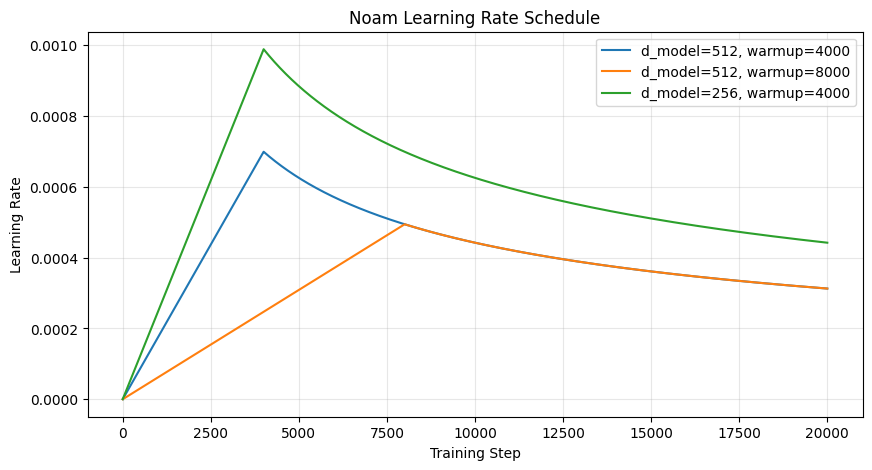

In [25]:
class NoamOpt:
    """Noam 学习率调度器"""
    def __init__(self, model_size, factor, warmup, optimizer):
        self.optimizer = optimizer
        self._step = 0
        self.warmup = warmup
        self.factor = factor
        self.model_size = model_size
        self._rate = 0

    def step(self):
        self._step += 1
        rate = self.rate()
        for p in self.optimizer.param_groups:
            p["lr"] = rate
        self._rate = rate
        self.optimizer.step()

    def rate(self, step=None):
        if step is None:
            step = self._step
        return self.factor * (
            self.model_size ** (-0.5)
            * min(step ** (-0.5), step * self.warmup ** (-1.5))
        )

# 可视化学习率调度
opts = [
    NoamOpt(512, 1, 4000, None),
    NoamOpt(512, 1, 8000, None),
    NoamOpt(256, 1, 4000, None),
]
steps = np.arange(1, 20000)
rates = [[opt.rate(s) for s in steps] for opt in opts]

plt.figure(figsize=(10, 5))
labels = ["d_model=512, warmup=4000",
          "d_model=512, warmup=8000",
          "d_model=256, warmup=4000"]
for rate, label in zip(rates, labels):
    plt.plot(steps, rate, label=label)
plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.title("Noam Learning Rate Schedule")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 11.3 简单训练循环演示

使用一个简单的复制任务（输入=输出）来演示训练过程。


In [26]:
class Batch:
    """封装一个 batch 的数据"""
    def __init__(self, src, trg=None, pad=0):
        self.src = src
        self.src_mask = (src != pad).unsqueeze(-2)
        if trg is not None:
            self.trg = trg[:, :-1]
            self.trg_y = trg[:, 1:]
            self.trg_mask = self.make_std_mask(self.trg, pad)
            self.ntokens = (self.trg_y != pad).data.sum()

    @staticmethod
    def make_std_mask(tgt, pad):
        tgt_mask = (tgt != pad).unsqueeze(-2)
        tgt_mask = tgt_mask & subsequent_mask(tgt.size(-1)).type_as(
            tgt_mask.data)
        return tgt_mask

def data_gen(V, batch_size, nbatches, seq_len=10):
    """生成随机数据"""
    for i in range(nbatches):
        data = torch.randint(1, V, (batch_size, seq_len))
        src = data.requires_grad_(False).clone()
        tgt = data.requires_grad_(False).clone()
        yield Batch(src, tgt, 0)

def run_epoch(data_iter, model, loss_compute):
    """运行一个 epoch"""
    total_loss = 0
    total_tokens = 0
    for batch in data_iter:
        out = model(batch.src, batch.trg, batch.src_mask, batch.trg_mask)
        loss = loss_compute(out, batch.trg_y, batch.ntokens)
        total_loss += loss
        total_tokens += batch.ntokens.item()
    return total_loss / max(total_tokens, 1)

class SimpleLossCompute:
    """简单的损失计算"""
    def __init__(self, generator, criterion, opt=None):
        self.generator = generator
        self.criterion = criterion
        self.opt = opt

    def __call__(self, x, y, norm):
        x = self.generator(x)
        loss = self.criterion(
            x.contiguous().view(-1, x.size(-1)),
            y.contiguous().view(-1)
        ) / norm
        loss.backward()
        if self.opt is not None:
            self.opt.step()
            self.opt.optimizer.zero_grad()
        return loss.data.item() * norm


In [27]:
# 训练演示
V = 11
train_model = make_model(V, V, N=2, d_model=64, d_ff=256, h=4)
criterion = LabelSmoothing(size=V, padding_idx=0, smoothing=0.0)
optimizer = torch.optim.Adam(
    train_model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9)
sched = NoamOpt(64, 1, 400, optimizer)
loss_fn = SimpleLossCompute(train_model.generator, criterion, sched)

losses = []
for epoch in range(10):
    train_model.train()
    data = list(data_gen(V, 30, 20))
    loss = run_epoch(iter(data), train_model, loss_fn)
    losses.append(loss)
    print(f"Epoch {epoch+1:2d} | Loss: {loss:.4f} | LR: {sched._rate:.6f}")


Epoch  1 | Loss: 2.7142 | LR: 0.000313


Epoch  2 | Loss: 2.1451 | LR: 0.000625


Epoch  3 | Loss: 1.6607 | LR: 0.000937


Epoch  4 | Loss: 1.2282 | LR: 0.001250


Epoch  5 | Loss: 0.9865 | LR: 0.001563


Epoch  6 | Loss: 0.8805 | LR: 0.001875


Epoch  7 | Loss: 0.7895 | LR: 0.002188


Epoch  8 | Loss: 0.7028 | LR: 0.002500


Epoch  9 | Loss: 0.6613 | LR: 0.002812


Epoch 10 | Loss: 0.6103 | LR: 0.003125


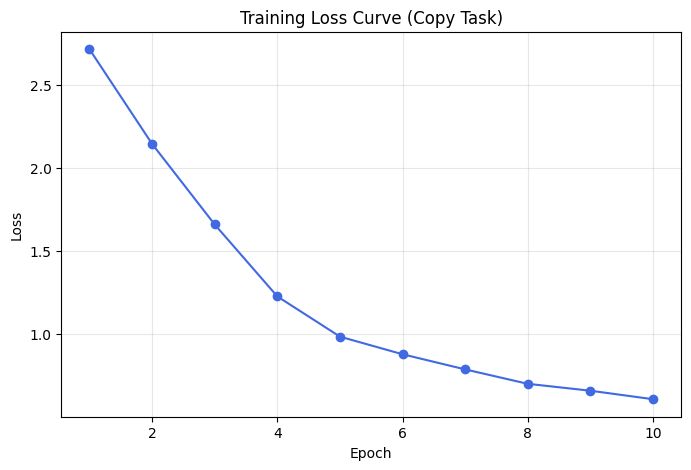

In [28]:
# 绘制训练损失曲线
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(losses)+1), losses, "o-", color="royalblue")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve (Copy Task)")
plt.grid(True, alpha=0.3)
plt.show()


## 12. 模型性能评估

### 12.1 贪心解码（Greedy Decoding）

推理时，逐步选择概率最高的词作为输出：


In [29]:
def greedy_decode(model, src, src_mask, max_len, start_symbol):
    """贪心解码"""
    memory = model.encode(src, src_mask)
    ys = torch.ones(1, 1).fill_(start_symbol).type_as(src.data)
    for i in range(max_len - 1):
        out = model.decode(
            memory, src_mask, ys,
            subsequent_mask(ys.size(1)).type_as(src.data)
        )
        prob = model.generator(out[:, -1])  # 只取最后一个位置
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.data[0]
        ys = torch.cat(
            [ys, torch.ones(1, 1).type_as(src.data).fill_(next_word)],
            dim=1)
    return ys

# 测试贪心解码
train_model.eval()
src_test = torch.LongTensor([[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]])
src_mask_test = torch.ones(1, 1, 10)
with torch.no_grad():
    result = greedy_decode(train_model, src_test, src_mask_test,
                           max_len=10, start_symbol=1)
print(f"输入: {src_test.tolist()[0]}")
print(f"输出: {result.tolist()[0]}")


输入: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
输出: [1, 10, 10, 10, 10, 10, 10, 10, 10, 10]


### 12.2 评估指标

常用的 Transformer 评估指标：

| 指标 | 公式 | 说明 |
|------|------|------|
| **Perplexity** | $e^{\text{loss}}$ | 困惑度，越低越好 |
| **Accuracy** | 正确预测数 / 总预测数 | 序列级准确率 |
| **BLEU** | n-gram 精度 | 机器翻译常用指标 |


In [30]:
# 计算评估指标
def compute_perplexity(loss):
    """从交叉熵损失计算困惑度"""
    return math.exp(loss)

def compute_accuracy(model, data_iter, V):
    """计算序列级准确率"""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in data_iter:
            out = model(batch.src, batch.trg,
                        batch.src_mask, batch.trg_mask)
            probs = model.generator(out)
            preds = probs.argmax(dim=-1)
            mask = batch.trg_y != 0
            correct += (preds[mask] == batch.trg_y[mask]).sum().item()
            total += mask.sum().item()
    return correct / max(total, 1)

# 评估训练后的模型
test_data = list(data_gen(V, 10, 5))
acc = compute_accuracy(train_model, iter(test_data), V)
ppl = compute_perplexity(losses[-1])
print(f"训练后 - 准确率: {acc:.4f}, 困惑度: {ppl:.4f}")


训练后 - 准确率: 0.8533, 困惑度: 1.8409


### 12.3 注意力权重分析（训练后）

观察训练后模型的注意力模式变化。


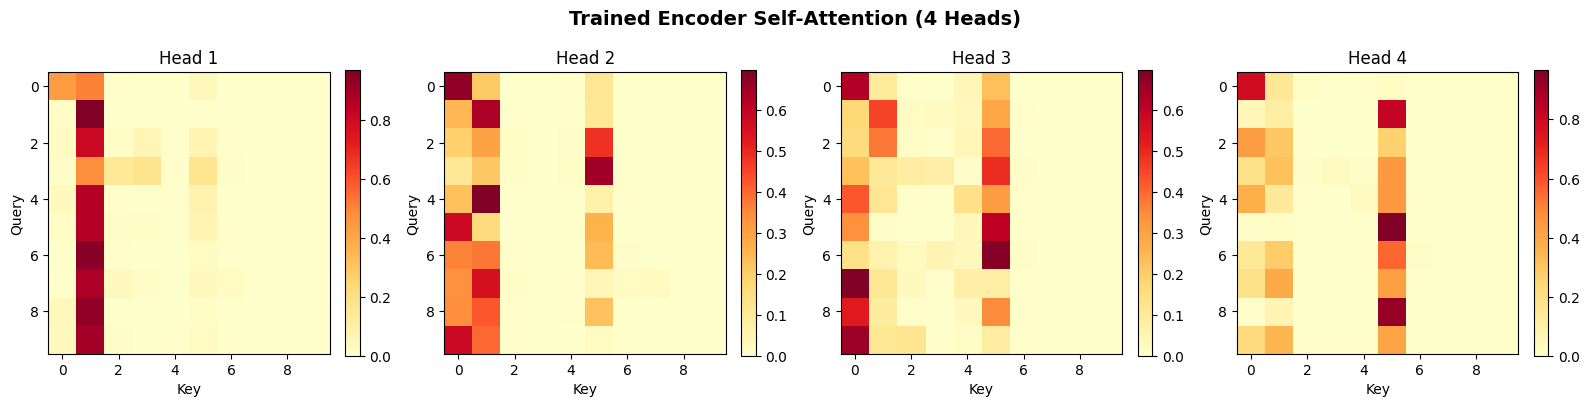

In [31]:
# 可视化训练后的注意力权重
train_model.eval()
enc_attn = train_model.encoder.layers[0].self_attn
enc_attn.eval()

with torch.no_grad():
    q = train_model.src_embed(src_test)
    _ = enc_attn(q, q, q, src_mask_test)
    attn_w = enc_attn.attn
    attn_probs = torch.exp(attn_w)[0].numpy()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Trained Encoder Self-Attention (4 Heads)",
             fontsize=14, fontweight="bold")
for i in range(4):
    im = axes[i].imshow(attn_probs[i], cmap="YlOrRd")
    axes[i].set_title(f"Head {i+1}")
    axes[i].set_xlabel("Key")
    axes[i].set_ylabel("Query")
    plt.colorbar(im, ax=axes[i], fraction=0.046)
plt.tight_layout()
plt.show()


## 13. 综合测试与总结

### 13.1 完整前向传播验证


In [32]:
# 完整前向传播测试
print("=" * 50)
print("Transformer Complete Forward Pass Test")
print("=" * 50)

model = make_model(11, 11, N=2)
params = sum(p.numel() for p in model.parameters())
print(f"\n参数量: {params:,}")

src = torch.LongTensor([[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]])
tgt = torch.LongTensor([[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]])
src_mask = torch.ones(1, 1, 10)
tgt_mask = subsequent_mask(10)

output = model(src, tgt, src_mask, tgt_mask)
print(f"输入形状: {src.shape}")
print(f"输出形状: {output.shape}")

# 贪心解码
model.eval()
with torch.no_grad():
    result = greedy_decode(model, src, src_mask,
                           max_len=10, start_symbol=1)
print(f"\n输入: {src.tolist()[0]}")
print(f"输出: {result.tolist()[0]}")
print("(未训练模型输出为随机结果)")

print("\n" + "=" * 50)
print("All tests completed successfully!")
print("=" * 50)


Transformer Complete Forward Pass Test



参数量: 14,731,787
输入形状: torch.Size([1, 10])
输出形状: torch.Size([1, 10, 512])

输入: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
输出: [1, 10, 10, 10, 10, 10, 10, 10, 6, 6]
(未训练模型输出为随机结果)

All tests completed successfully!


### 13.2 总结

本 Notebook 完整实现了 Transformer 模型的所有核心组件：

1. **注意力机制**：Scaled Dot-Product Attention → Multi-Head Attention
2. **位置编码**：正弦/余弦编码注入位置信息
3. **编码器**：N 层 Self-Attention + FFN，残差连接 + LayerNorm
4. **解码器**：N 层 Masked Self-Attention + Cross-Attention + FFN
5. **训练技术**：Noam 学习率调度、标签平滑
6. **推理方法**：贪心解码

**关键设计思想**：
- 残差连接确保梯度在深层网络中稳定传播
- 多头注意力让模型同时关注不同子空间的信息
- 位置编码弥补了自注意力缺乏位置感知的不足
- 标签平滑防止过拟合，提升泛化能力
